In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [50]:
dataset_path = './Dataset/carv4.csv'

car_raw = pd.read_csv(dataset_path)

In [51]:
car_raw.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0


In [34]:
car_raw.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,1995.000000,1995.000000,1995.000000,1995.000000,1946.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4280.860652,1767.991980,1591.735338,5.306266,52.002210
std,2.419881e+06,3.363564,5.736172e+04,442.458507,135.265825,136.073956,0.822170,15.110198
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3985.000000,1695.000000,1485.000000,5.000000,41.250000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4629.000000,1831.500000,1675.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Year'}>,
        <Axes: title={'center': 'Kilometer'}>],
       [<Axes: title={'center': 'Length'}>,
        <Axes: title={'center': 'Width'}>,
        <Axes: title={'center': 'Height'}>],
       [<Axes: title={'center': 'Seating Capacity'}>,
        <Axes: title={'center': 'Fuel Tank Capacity'}>, <Axes: >]],
      dtype=object)

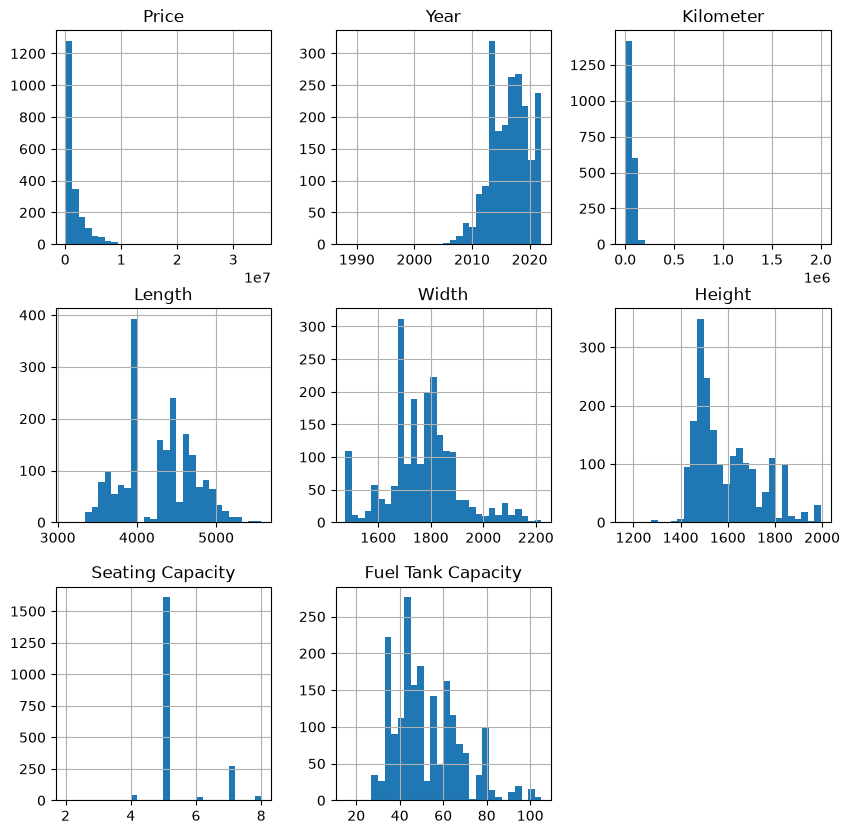

In [ ]:
car_raw.hist(bins=30, figsize=(10,10))

In [52]:
from sklearn.model_selection import train_test_split

car_train, car_test = train_test_split(car_raw, test_size=0.2,
                                    random_state=42)

In [53]:
car_df = car_train
car_test.head()
#car_raw['Location'].value_counts()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
1298,BMW,X5 xDrive 30d Expedition,4800000,2017,35000,Diesel,Automatic,Delhi,Black,First,Individual,2993 cc,258 bhp @ 4000 rpm,560 Nm @ 1500 rpm,AWD,4886.0,1938.0,1762.0,7.0,NaN
591,Maruti Suzuki,Vitara Brezza VDi,825000,2018,48174,Diesel,Manual,Thane,White,First,Individual,1248 cc,89 bhp @ 4000 rpm,200 Nm @ 1750 rpm,FWD,3995.0,1790.0,1640.0,5.0,48.0
1318,Maruti Suzuki,Baleno Zeta 1.3,695000,2016,68921,Diesel,Manual,Hyderabad,Red,First,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1745.0,1500.0,5.0,37.0
1067,Skoda,Rapid Ambition 1.6 TDI CR MT,950000,2019,32809,Diesel,Manual,Coimbatore,Silver,First,Individual,1598 cc,105 bhp @ 4400 rpm,250 Nm @ 2500 rpm,FWD,4386.0,1699.0,1466.0,5.0,55.0
29,Honda,WR-V VX MT Petrol,819999,2018,27963,Petrol,Manual,Delhi,White,First,Individual,1199 cc,89 bhp @ 6000 rpm,110 Nm @ 4800 rpm,FWD,3999.0,1734.0,1601.0,5.0,40.0


Changing City Name to Latitude and Longitude

In [75]:
indian_cood = pd.read_csv('./Dataset/IndianCityCoordinates/data3.csv')

# 3.5 Manually patch the missing cities (keys must be lowercase)
missing_coords = {
    'ambala cantt': (30.3340, 76.8400),
    'noida': (28.5355, 77.3910),
    'bangalore': (12.9716, 77.5946),
    'kanpur': (26.4499, 80.3319),
    'gurgaon': (28.4595, 77.0266),
    'thane': (19.2183, 72.9781),
    'mohali': (30.7046, 76.7179),
    'zirakpur': (30.6425, 76.8173),
    'kheda': (22.7533, 72.6833),
    'nagpur': (21.1458, 79.0882),
    'goa': (15.2993, 74.1240),
    'jalandhar': (31.3260, 75.5762),
    'haldwani': (29.2183, 79.5126),
    'nashik': (20.0059, 73.7629),
    'bulandshahar': (28.4069, 77.8498),
    'navi mumbai': (19.0330, 73.0297),
    'yamunanagar': (30.1290, 77.2674),
    'rudrapur': (28.9816, 79.4000),
    'faizabad': (26.7730, 82.1460),
    'valsad': (20.5992, 72.9342),
    'gorakhpur': (26.7606, 83.3732),
    'pimpri-chinchwad': (18.6298, 73.7997),
    'udupi': (13.3409, 74.7421),
    'roorkee': (29.8543, 77.8880),
    'panvel': (18.9894, 73.1175),
    'deoghar': (24.4841, 86.6961),
    'dharwad': (15.4589, 75.0078),
    'samastipur': (25.8628, 85.7810),
    'dak. kannada': (12.8647, 75.2415),
    'kharar': (30.7492, 76.6412),
    'unnao': (26.5393, 80.4878),
    'bhubaneswar': (20.2961, 85.8245),
    'siliguri': (26.7271, 88.3953),
    'ranga reddy': (17.3323, 78.0401),
    'ernakulam': (9.9816, 76.2999)
}

In [80]:
car_df['match_city'] = car_df['Location'].str.lower()
indian_cood['match_city'] = indian_cood['city'].str.strip().str.lower()

lat_map = indian_cood.set_index('match_city')['lat'].to_dict()
lng_map = indian_cood.set_index('match_city')['lng'].to_dict()

car_df['Latitude'] = car_df['match_city'].map(lat_map)
car_df['Longitude'] = car_df['match_city'].map(lng_map)


car_df.head()

for city, (lat, lng) in missing_coords.items():
    lat_map[city] = lat
    lng_map[city] = lng


car_df['Latitude'] = car_df['match_city'].map(lat_map)
car_df['Longitude'] = car_df['match_city'].map(lng_map)

car_df = car_df.drop(columns=['match_city'])

car_df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,...,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Latitude,Longitude
0,BMW,3-Series 320d,800000,2012,75576,Diesel,Automatic,Mumbai,White,Second,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.987807,72.836447
1,BMW,X1 sDrive20d xLine,2199000,2016,77000,Diesel,Automatic,Surat,Black,First,...,184 bhp @ 4000 rpm,350 Nm @ 1750 rpm,RWD,4454.0,2044.0,1545.0,5.0,63.0,21.195944,72.830232
2,Mahindra,XUV500 W4 1.99,800000,2017,112000,Diesel,Manual,Muzaffurpur,Silver,First,...,138 bhp @ 3750 rpm,320 Nm @ 1600 rpm,FWD,4585.0,1890.0,1785.0,7.0,70.0,26.122593,85.390553
3,Mercedes-Benz,GLS 400d 4MATIC,12900000,2021,3000,Diesel,Automatic,Delhi,White,First,...,326 bhp @ 3600 rpm,700 Nm @ 1200 rpm,AWD,5207.0,2157.0,1823.0,7.0,90.0,28.651952,77.231495
4,Toyota,Fortuner 2.8 4x2 AT [2016-2020],3499000,2019,73000,Diesel,Automatic,Mumbai,White,First,...,174 bhp @ 3400 rpm,450 Nm @ 1600 rpm,RWD,4795.0,1855.0,1835.0,7.0,80.0,18.987807,72.836447


<Axes: xlabel='Longitude', ylabel='Latitude'>

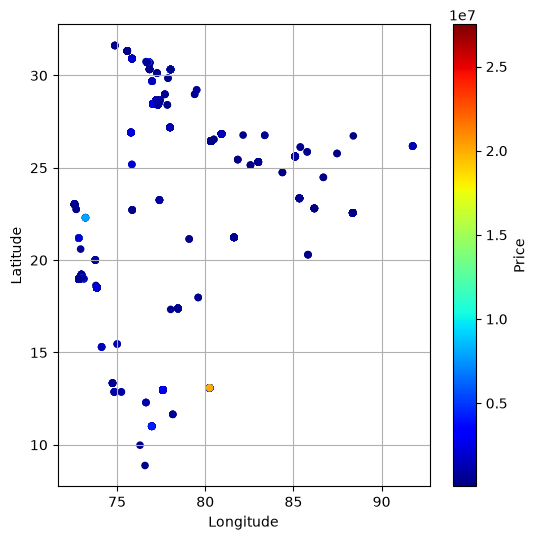

In [ ]:
car_df.plot(kind="scatter", x="Longitude", y="Latitude", grid=True, figsize=(6,6), c="", cmap="jet")
#i dont think it was worth the effort 😭